# 02 — Filters and within-day score distribution (S2 look)

Workstream 2 exploratory pass on the **FNSPID primary spine**.
No return regressions. No aggregator selection. Development / evaluation
labels are the frozen chronological evaluation block
(`≤ 2019-12-31` / `≥ 2020-01-01`).

**In scope here**
- Within-firm-day FinBERT score moments and polarity mix
- How those moments move with story-count bins (`1`, `2-5`, `6-20`, `21-75`, `76+`)
- Where panel mass sits (firm-days vs articles)
- Novelty stack on checkpoint headlines: strictly-earlier first-mention,
  30d exact/near-dup, market-recap flag, time-since-prior-story-date
- Blinded stratified audit template plus separate sampling-weight key
- Explicit blockers: publisher / site identity, `story_family_id`, filled audit labels

**Not in scope here**
- Publisher weighting tests (no site column on the checkpoint grain)
- Filter precision/recall claims (need human labels)
- Any sentiment → return model

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from repo root or final_experiments/")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.distribution import (  # noqa: E402
    N_BIN_ORDER,
    build_distribution_tables,
)
from final_experiments.lib.novelty import (  # noqa: E402
    AUDIT_N_DEFAULT,
    AUDIT_SEED_DEFAULT,
    NOVELTY_CLASSES,
    NoveltyConfig,
    build_novelty_tables,
)
from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_EVENTS_DB,
    FROZEN_DEV_END,
    FROZEN_EVAL_START,
)

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: object) -> None:
        print(obj)


plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "02_filters_and_distribution"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PANEL_PATH = REPO_ROOT / "final_experiments" / "outputs" / "01_panel" / "fnspid_firm_day_panel.parquet"
print("panel:", PANEL_PATH)
print("events:", DEFAULT_EVENTS_DB)
print("output:", OUTPUT_DIR)
print(f"frozen split: development ≤ {FROZEN_DEV_END}; evaluation ≥ {FROZEN_EVAL_START}")

panel: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/01_panel/fnspid_firm_day_panel.parquet
events: /Users/peterprendergast/Documents/Sentiment_Dissertation/reports/loop_moment2_finbert_20260719/finbert_checkpoint.sqlite3
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/02_filters_and_distribution
frozen split: development ≤ 2019-12-31; evaluation ≥ 2020-01-01


## 0. Load panel and build firm-day moments

Moments are recomputed from story-level FinBERT scores on the executable
panel keys (news ∩ tradable open ∩ SPY). Headlines stay in the SQLite
checkpoint and are not written to outputs.

In [2]:
panel = pd.read_parquet(PANEL_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
tables = build_distribution_tables(panel, events_db=DEFAULT_EVENTS_DB)
moments = tables["moments"]
mass = tables["mass"]
by_bin = tables["by_n_bin"]

print(f"stories={tables['n_stories']:,}  firm_days={tables['n_firm_days']:,}  panel_keys={tables['n_panel_keys']:,}")
assert tables["n_firm_days"] == tables["n_panel_keys"], "moments grain must match panel keys"
display(pd.Series(tables["split_counts"], name="firm_days").to_frame())

moments.to_parquet(OUTPUT_DIR / "firm_day_moments.parquet", index=False)
mass.to_csv(OUTPUT_DIR / "mass_by_n_bin.csv")
by_bin.to_csv(OUTPUT_DIR / "moments_by_n_bin.csv")

stories=1,599,451  firm_days=715,546  panel_keys=715,546


,firm_days
development,512153
evaluation,203393


## 1. Where the mass sits

Most firm-days are low-n. Article mass is less skewed toward n=1 because
high-n days contribute many headlines. Aggregators that only work when
n is large apply to a minority of firm-days.

,firm_days,articles,firm_day_share,article_share
n_bin,,,,
1,362438,362438.0,0.506519,0.226602
2-5,311647,848956.0,0.435537,0.530780
6-20,39703,337824.0,0.055486,0.211212
21-75,1745,48478.0,0.002439,0.030309
76+,13,1755.0,0.000018,0.001097


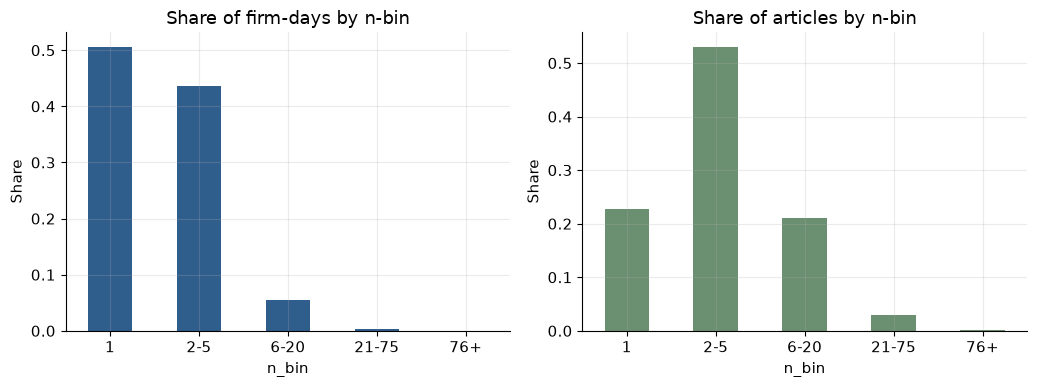

Firm-days with n≤5: 94.2% of the panel.
Firm-days with n≥6: 5.8% but 24.3% of articles.


In [3]:
display(mass)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
mass.loc[N_BIN_ORDER, "firm_day_share"].plot(kind="bar", ax=axes[0], color="#2f5d8c", rot=0)
axes[0].set_title("Share of firm-days by n-bin")
axes[0].set_ylabel("Share")
mass.loc[N_BIN_ORDER, "article_share"].plot(kind="bar", ax=axes[1], color="#6b8f71", rot=0)
axes[1].set_title("Share of articles by n-bin")
axes[1].set_ylabel("Share")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mass_by_n_bin.png", dpi=140)
plt.show()

low_n = mass.loc[["1", "2-5"], "firm_day_share"].sum()
print(f"Firm-days with n≤5: {low_n:.1%} of the panel.")
print(
    f"Firm-days with n≥6: {mass.loc[['6-20', '21-75', '76+'], 'firm_day_share'].sum():.1%} "
    f"but {mass.loc[['6-20', '21-75', '76+'], 'article_share'].sum():.1%} of articles."
)

## 2. Within-day moments vs n

Equal firm-day weight within each bin. Watch mean–median gap, dispersion,
and polarity shares as n grows — this is the count-conditioned bias the
plan flags.

,firm_days,mean,median,std,skew,mean_minus_median,share_negative,share_neutral,share_positive,recap_share
n_bin,,,,,,,,,,
1,362438,0.0869,0.0869,0.0000,0.0000,0.0000,0.1340,0.6488,0.2172,0.0948
2-5,311647,0.0786,0.0773,0.3176,0.0322,0.0013,0.1560,0.6155,0.2285,0.0908
6-20,39703,0.0465,0.0402,0.4560,0.0529,0.0063,0.1974,0.5569,0.2457,0.1086
21-75,1745,-0.0192,-0.0170,0.5137,-0.0234,-0.0022,0.2573,0.4978,0.2448,0.1538
76+,13,0.1172,0.0782,0.3103,2.6410,0.0390,0.0821,0.7567,0.1611,0.0302


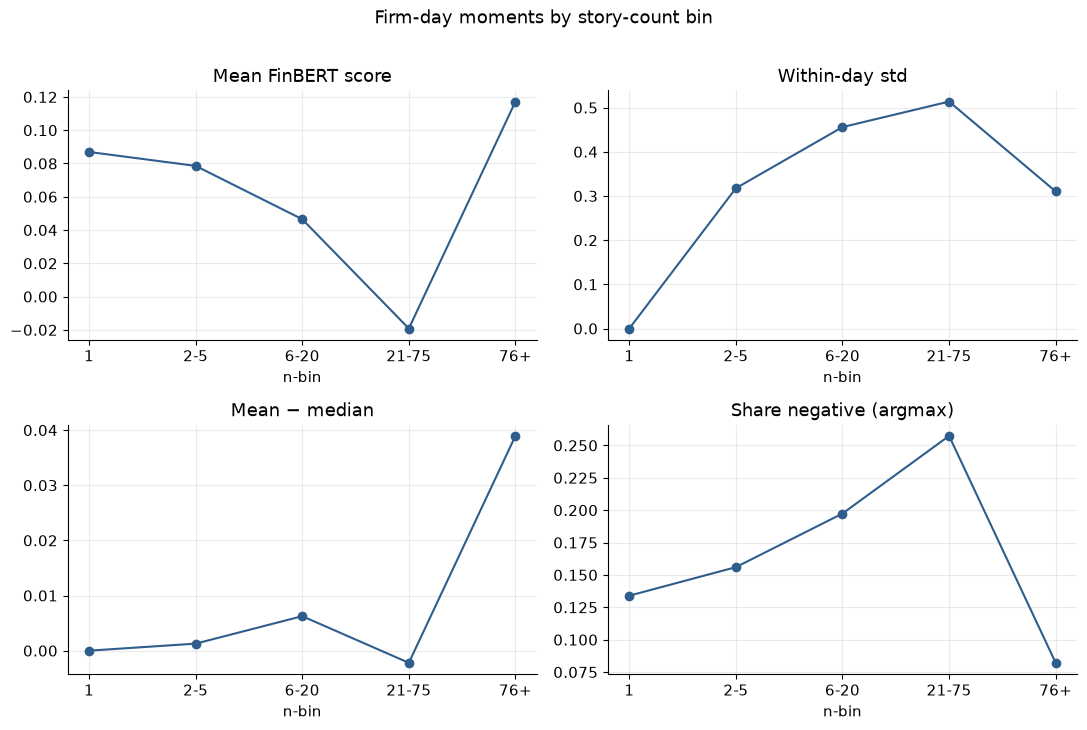

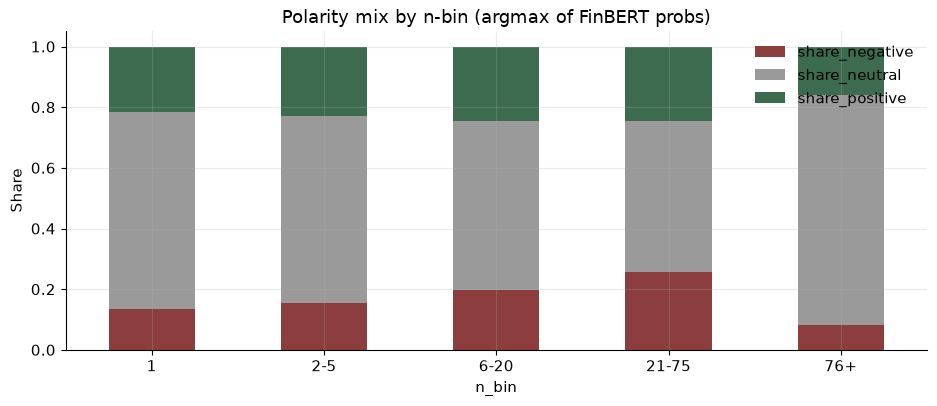

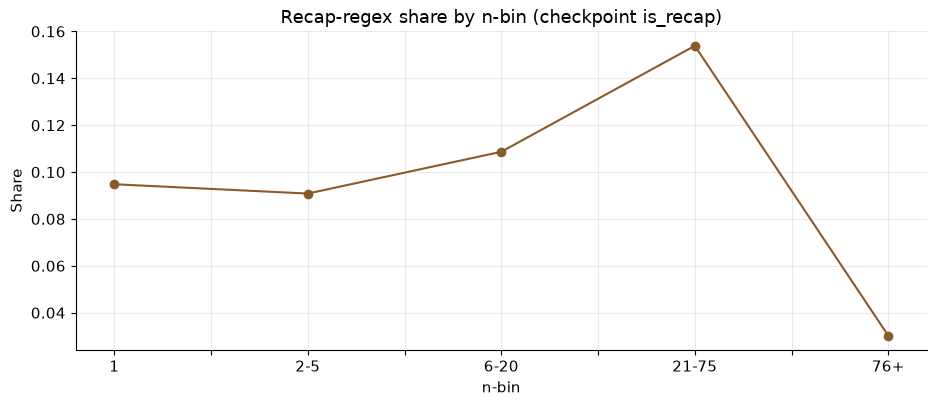

In [4]:
moment_cols = [
    "mean",
    "median",
    "std",
    "skew",
    "mean_minus_median",
    "share_negative",
    "share_neutral",
    "share_positive",
    "recap_share",
]
means = moments.groupby("n_bin", observed=True)[moment_cols].mean().reindex(N_BIN_ORDER)
counts = moments.groupby("n_bin", observed=True).size().reindex(N_BIN_ORDER)
summary = means.copy()
summary.insert(0, "firm_days", counts)
display(summary.round(4))
summary.to_csv(OUTPUT_DIR / "moment_means_by_n_bin.csv")

fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))
plot_specs = [
    (axes[0, 0], "mean", "Mean FinBERT score"),
    (axes[0, 1], "std", "Within-day std"),
    (axes[1, 0], "mean_minus_median", "Mean − median"),
    (axes[1, 1], "share_negative", "Share negative (argmax)"),
]
for ax, col, title in plot_specs:
    means[col].plot(ax=ax, marker="o", color="#2f5d8c")
    ax.set_title(title)
    ax.set_xlabel("n-bin")
fig.suptitle("Firm-day moments by story-count bin", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "moments_vs_n.png", dpi=140)
plt.show()

fig, ax = plt.subplots()
pol = means[["share_negative", "share_neutral", "share_positive"]]
pol.plot(kind="bar", stacked=True, ax=ax, rot=0, color=["#8c3d3d", "#9a9a9a", "#3d6b4f"])
ax.set_title("Polarity mix by n-bin (argmax of FinBERT probs)")
ax.set_ylabel("Share")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "polarity_mix_by_n.png", dpi=140)
plt.show()

fig, ax = plt.subplots()
means["recap_share"].plot(ax=ax, marker="o", color="#8a5a2b")
ax.set_title("Recap-regex share by n-bin (checkpoint is_recap)")
ax.set_ylabel("Share")
ax.set_xlabel("n-bin")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "recap_share_by_n.png", dpi=140)
plt.show()

## 3. Development vs evaluation (descriptive only)

Same moments, split by the frozen chronological boundary. Not a test —
just a check that the count structure is not wildly different across the cut.

split,development,evaluation
n_bin,,
1,0.4832,0.5653
2-5,0.4540,0.3891
6-20,0.0602,0.0437
21-75,0.0027,0.0019
76+,0.0000,0.0001


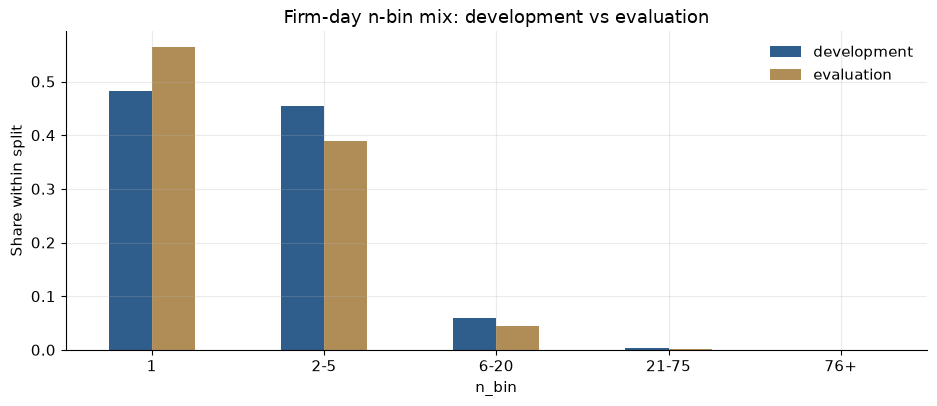

In [5]:
split_mass = (
    moments.groupby(["split", "n_bin"], observed=True)
    .size()
    .rename("firm_days")
    .groupby(level=0)
    .transform(lambda s: s / s.sum())
    .rename("firm_day_share")
    .reset_index()
)
pivot = split_mass.pivot(index="n_bin", columns="split", values="firm_day_share").reindex(N_BIN_ORDER)
display(pivot.round(4))
pivot.to_csv(OUTPUT_DIR / "n_bin_share_by_split.csv")

fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax, rot=0, color=["#2f5d8c", "#b08d57"])
ax.set_title("Firm-day n-bin mix: development vs evaluation")
ax.set_ylabel("Share within split")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "n_bin_by_split.png", dpi=140)
plt.show()

## 4. Novelty features and heuristic class mix

Checkpoint grain has `headline` + `is_recap`; no `story_family_id`.
Features (trailing 30 calendar days within firm):
first-mention, exact hash repeat, Jaccard near-dup (≥0.80), days since prior
story date, market-recap flag. Family-revision count stays null.

Repetition rule (uncalibrated heuristic): exact or near-duplicate against a
**strictly earlier** firm date → `repetition`; else
`novel_or_unclassified`. Market recap is an orthogonal flag, not routine
scheduled reporting. Same-session ordering is unavailable at this grain.

novelty stories=1,599,451  window=30d  jaccard≥0.8


,novelty_class,n,share
0,novel_or_unclassified,1553496,0.971268
1,repetition,45955,0.028732


,novelty_config
window_days,30
jaccard_threshold,0.8
family_revision_count,null — story_family_id absent from checkpoint
classifier,heuristic_uncalibrated
comparison_timing,strictly_earlier_firm_dates_only
market_recap_role,orthogonal_flag_not_routine_reporting
routine_reporting_status,unavailable_on_checkpoint_grain
audit_seed,42
audit_n,180
audit_design,blinded_stratified_with_separate_weight_key


blinded audit template: 180 rows → /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/02_filters_and_distribution/novelty_audit_sample.csv; separate predictions/weights → /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/02_filters_and_distribution/novelty_audit_key.csv (seed=42)
Fill human_novelty_class before claiming filter precision.


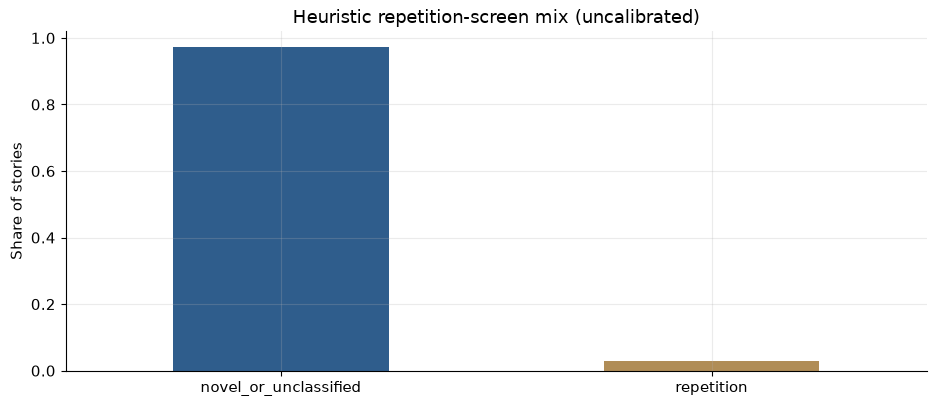

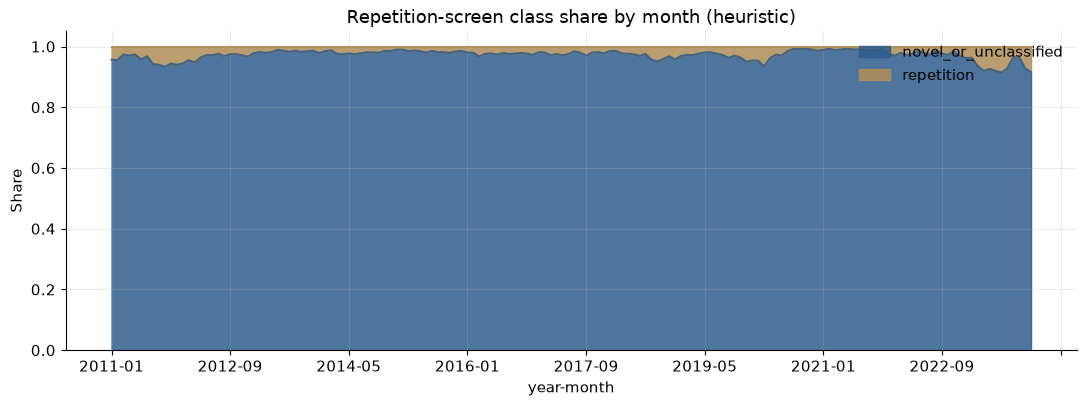

Firms with highest mean monthly repetition share (top 10):


,share_novel_or_unclassified,share_repetition,share_market_recap,n_stories
symbol,,,,
UNG,0.813,0.161,0.065,25.122
USO,0.866,0.134,0.050,32.513
QQQ,0.906,0.081,0.304,75.718
XLE,0.923,0.077,0.057,38.994
TIP,0.890,0.071,0.039,12.359
ARR,0.900,0.068,0.123,11.968
XLF,0.933,0.067,0.054,41.564
EMB,0.916,0.065,0.019,8.000
XLK,0.936,0.064,0.044,35.199


In [6]:
novelty_cfg = NoveltyConfig(window_days=30, jaccard_threshold=0.80)
novelty = build_novelty_tables(
    panel,
    events_db=DEFAULT_EVENTS_DB,
    config=novelty_cfg,
    audit_n=AUDIT_N_DEFAULT,
    audit_seed=AUDIT_SEED_DEFAULT,
)
annotated = novelty["annotated"]
overall = novelty["overall"]
by_firm_month = novelty["by_firm_month"]
audit = novelty["audit_sample"]
audit_key = novelty["audit_key"]

print(f"novelty stories={novelty['n_stories']:,}  window={novelty_cfg.window_days}d  jaccard≥{novelty_cfg.jaccard_threshold}")
display(overall)
display(pd.Series(novelty["config"], name="novelty_config").to_frame())

annotated.to_parquet(OUTPUT_DIR / "story_novelty.parquet", index=False)
overall.to_csv(OUTPUT_DIR / "novelty_mix_overall.csv", index=False)
by_firm_month.to_parquet(OUTPUT_DIR / "novelty_mix_by_firm_month.parquet", index=False)
# Headlines only in the blinded local worksheet (outputs/ is gitignored).
audit.to_csv(OUTPUT_DIR / "novelty_audit_sample.csv", index=False)
audit_key.to_csv(OUTPUT_DIR / "novelty_audit_key.csv", index=False)
print(
    f"blinded audit template: {len(audit)} rows → "
    f"{OUTPUT_DIR / 'novelty_audit_sample.csv'}; separate predictions/weights → "
    f"{OUTPUT_DIR / 'novelty_audit_key.csv'} (seed={AUDIT_SEED_DEFAULT})"
)
print("Fill human_novelty_class before claiming filter precision.")

fig, ax = plt.subplots()
overall_plot = overall.set_index("novelty_class").reindex(list(NOVELTY_CLASSES))
overall_plot["share"].plot(kind="bar", ax=ax, color=["#2f5d8c", "#b08d57"], rot=0)
ax.set_title("Heuristic repetition-screen mix (uncalibrated)")
ax.set_ylabel("Share of stories")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "novelty_mix_overall.png", dpi=140)
plt.show()

monthly = (
    annotated.assign(year_month=lambda d: pd.to_datetime(d["session_date"]).dt.to_period("M").astype(str))
    .groupby(["year_month", "novelty_class"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=list(NOVELTY_CLASSES), fill_value=0)
)
monthly_share = monthly.div(monthly.sum(axis=1).clip(lower=1), axis=0)
fig, ax = plt.subplots(figsize=(11, 4.2))
monthly_share.plot.area(ax=ax, color=["#2f5d8c", "#b08d57"], alpha=0.85)
ax.set_title("Repetition-screen class share by month (heuristic)")
ax.set_ylabel("Share")
ax.set_xlabel("year-month")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "novelty_mix_by_month.png", dpi=140)
plt.show()

firm_means = (
    by_firm_month.groupby("symbol", observed=True)[["share_novel_or_unclassified", "share_repetition", "share_market_recap", "n_stories"]]
    .mean()
    .sort_values("share_repetition", ascending=False)
)
print("Firms with highest mean monthly repetition share (top 10):")
display(firm_means.head(10).round(3))

## 5. Publisher / remaining blockers (read, do not invent)

Publisher identity is still absent from the FinBERT checkpoint. Novelty
features above do **not** invent site/publisher or family revision lineage.
The audit CSV is a template only until `human_novelty_class` is filled.

In [7]:
blockers = pd.DataFrame(
    [
        {
            "item": "publisher / FNSPID site table",
            "status": "blocked",
            "note": "null on panel; absent from finbert_checkpoint.sqlite3 events schema",
        },
        {
            "item": "publisher tiers + weighting test",
            "status": "blocked",
            "note": "needs publisher identity; do not infer tiers from returns",
        },
        {
            "item": "novelty.py (first-mention, near-dup, family revision)",
            "status": "built_partial",
            "note": "first-mention / 30d exact+near-dup / recap / time-since-last built; family_revision_count null (no story_family_id)",
        },
        {
            "item": "strictly-earlier repetition screen",
            "status": "heuristic_uncalibrated",
            "note": "repetition vs novel_or_unclassified; same-session ordering unavailable",
        },
        {
            "item": "breaking / routine scheduled-reporting classifier",
            "status": "blocked_on_checkpoint_grain",
            "note": "market recap remains separate; routine needs human labels or event taxonomy",
        },
        {
            "item": "hand-labelled audit sample (150–200)",
            "status": "template_ready_labels_empty",
            "note": f"blind sample + separate weighted key n={len(audit)} seed={AUDIT_SEED_DEFAULT}; fill labels locally",
        },
        {
            "item": "recap-regex flag",
            "status": "available",
            "note": "checkpoint is_recap retained as market-recap flag; never called routine",
        },
        {
            "item": "within-day score distribution EDA",
            "status": "done_this_notebook",
            "note": "moments + mass + polarity vs n; no returns",
        },
    ]
)
display(blockers)
blockers.to_csv(OUTPUT_DIR / "w2_blockers.csv", index=False)

,item,status,note
0,publisher / FNSPID site table,blocked,null on panel; absent from finbert_checkpoint....
1,publisher tiers + weighting test,blocked,needs publisher identity; do not infer tiers f...
2,"novelty.py (first-mention, near-dup, family re...",built_partial,first-mention / 30d exact+near-dup / recap / t...
3,strictly-earlier repetition screen,heuristic_uncalibrated,repetition vs novel_or_unclassified; same-sess...
4,breaking / routine scheduled-reporting classifier,blocked_on_checkpoint_grain,market recap remains separate; routine needs h...
5,hand-labelled audit sample (150–200),template_ready_labels_empty,blind sample + separate weighted key n=180 see...
6,recap-regex flag,available,checkpoint is_recap retained as market-recap f...
7,within-day score distribution EDA,done_this_notebook,moments + mass + polarity vs n; no returns


## 6. Berkson / collider warning

The executable panel is the **intersection** of (a) at least one scored
headline mapping to the session and (b) a tradable adjusted open with SPY
on that session. Conditioning on coverage and on executability is itself a
selection. Firm-days with no news are absent; firms missing prices
(SEE, SKYW, SOL) are absent; low-coverage names appear only on their news
days. Later return regressions that treat this panel as a random sample of
firm-days will inherit that collider. State it; do not "fix" it by
inventing zero-news rows here.

In [8]:
manifest = {
    "notebook": "02_filters_and_distribution",
    "built_for": "Workstream 2 EDA / novelty heuristics",
    "primary_spine": "FNSPID",
    "frozen_split": {
        "development_end": FROZEN_DEV_END,
        "evaluation_start": FROZEN_EVAL_START,
    },
    "n_stories": tables["n_stories"],
    "n_firm_days": tables["n_firm_days"],
    "mass_by_n_bin": mass.reset_index().to_dict(orient="records"),
    "firm_days_n_le_5_share": float(low_n),
    "novelty": {
        **novelty["config"],
        "n_stories": novelty["n_stories"],
        "class_mix": overall.to_dict(orient="records"),
        "family_revision_count": "null — story_family_id absent",
        "audit_labels_filled": False,
        "audit_key_file": "novelty_audit_key.csv",
    },
    "collider_warning": ("Panel = news-bearing ∩ tradable open ∩ SPY; not a random firm-day sample."),
    "publisher_status": "blocked_on_checkpoint_schema",
    "returns_analysed": False,
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "notebook": "02_filters_and_distribution",
  "built_for": "Workstream 2 EDA / novelty heuristics",
  "primary_spine": "FNSPID",
  "frozen_split": {
    "development_end": "2019-12-31",
    "evaluation_start": "2020-01-01"
  },
  "n_stories": 1599451,
  "n_firm_days": 715546,
  "mass_by_n_bin": [
    {
      "n_bin": "1",
      "firm_days": 362438,
      "articles": 362438.0,
      "firm_day_share": 0.5065194969994941,
      "article_share": 0.22660150264059356
    },
    {
      "n_bin": "2-5",
      "firm_days": 311647,
      "articles": 848956.0,
      "firm_day_share": 0.4355373379209722,
      "article_share": 0.5307796237584022
    },
    {
      "n_bin": "6-20",
      "firm_days": 39703,
      "articles": 337824.0,
      "firm_day_share": 0.055486299972328824,
      "article_share": 0.21121247227955092
    },
    {
      "n_bin": "21-75",
      "firm_days": 1745,
      "articles": 48478.0,
      "firm_day_share": 0.002438697162726086,
      "article_share": 0.0303091498270344

### Carry-forward

1. Most firm-days are n≤5 — any “distribution-aware” aggregator claim must
   be stratified by n or it is mostly a claim about rare high-n days.
2. Mean–median gap and polarity mix by bin remain the distribution figures
   to re-read before any RQ choice.
3. The repetition screen is a **heuristic** on Spine A; routine reporting
   remains unavailable; fill the blinded audit before precision claims.
4. Still no return model in this notebook — correctly so for S2.